# Tarea 2: Regresión
### Predicción de la nota media del segundo semestre

**Objetivo:** Predecir `nota_media_2sem` usando información previa al segundo semestre.  
Se comparan dos modelos:
- **Regresión Lineal** (implementación propia, mínimos cuadrados y gradient descent)
- **SVR** (Support Vector Regression, sklearn) como modelo no lineal

**Pipeline:**
1. Carga y exploración de la variable objetivo
2. Selección de variables y justificación de exclusiones (data leakage)
3. Preprocesado, permutación y split train/test
4. Regresión Lineal — mínimos cuadrados
5. Regresión Lineal — gradient descent
6. SVR con kernel RBF
7. Comparativa final de modelos

## 0. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to sys.path
sys.path.insert(0, project_root)

from src.linear_regressor import LinearRegressor, evaluate_regression, one_hot_encode

SEED = 42
np.random.seed(SEED)

## 1. Carga del dataset y exploración de la variable objetivo

In [21]:
df = pd.read_csv('../data/rendimiento_estudiantes.csv', sep=';')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (4424, 37)


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


In [22]:
target = 'nota_media_2sem'

print('Estadísticas descriptivas de nota_media_2sem:')
print(df[target].describe().round(3))
print(f'\nEstudiantes con nota = 0: {(df[target] == 0).sum()} '
      f'({(df[target] == 0).mean()*100:.1f}%)')

Estadísticas descriptivas de nota_media_2sem:
count    4424.000
mean       10.230
std         5.211
min         0.000
25%        10.750
50%        12.200
75%        13.333
max        18.571
Name: nota_media_2sem, dtype: float64

Estudiantes con nota = 0: 870 (19.7%)


### 📊 Interpretación: distribución de la variable objetivo

La distribución de `nota_media_2sem` tiene dos características relevantes:

1. **Pico en 0 (19.7% del dataset, n=870):** estos estudiantes no llegaron a examinarse en el 2º semestre, bien por abandono, bien por no presentarse. Incluirlos mezclaría dos fenómenos distintos (ausencia de actividad vs rendimiento bajo), distorsionando el modelo. Se filtran en la siguiente celda.

2. **Entre quienes sí cursaron el 2º semestre:** la distribución es aproximadamente normal sesgada a la izquierda, con mediana 12.2 y percentil 25 en 10.75. La mayoría de los estudiantes activos obtienen notas en el rango 10-14, lo que indica un nivel académico medio-alto entre quienes continúan.

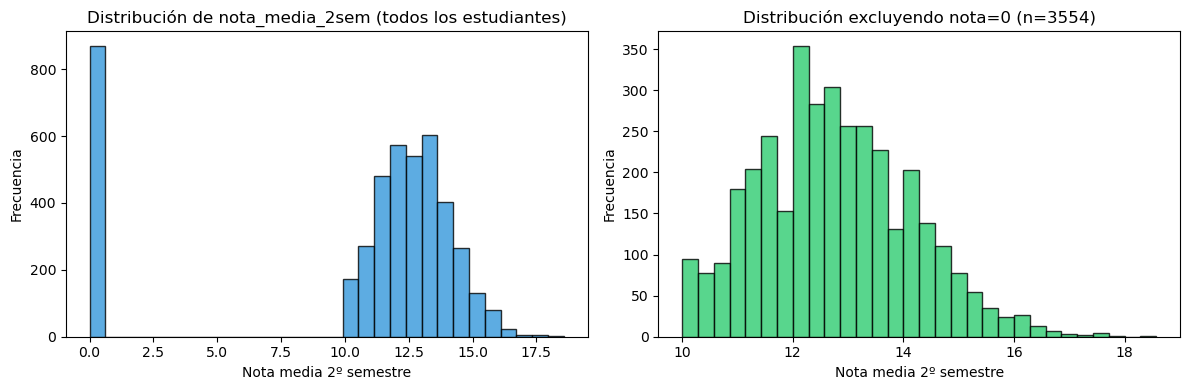

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[target], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución de nota_media_2sem (todos los estudiantes)')
axes[0].set_xlabel('Nota media 2º semestre')
axes[0].set_ylabel('Frecuencia')

df_nonzero = df[df[target] > 0]
axes[1].hist(df_nonzero[target], bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title(f'Distribución excluyendo nota=0 (n={len(df_nonzero)})')
axes[1].set_xlabel('Nota media 2º semestre')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [24]:
# Trabajamos solo con estudiantes que tienen nota > 0.
# Los estudiantes con nota=0 no llegaron a examinarse (abandonos o sin actividad),
# lo que introduciría un sesgo en el modelo de rendimiento.
df_model = df[df[target] > 0].copy().reset_index(drop=True)
print(f'Dataset tras filtrar nota=0: {df_model.shape[0]} estudiantes')

Dataset tras filtrar nota=0: 3554 estudiantes


## 2. Selección de variables y justificación de exclusiones

### Variables excluidas por data leakage

Las siguientes variables no pueden usarse como predictores:

| Variable excluida | Motivo |
|---|---|
| `asignaturas_2sem_matriculadas` | Información del mismo período que el target |
| `asignaturas_2sem_evaluadas` | Directamente ligada al rendimiento en 2º sem |
| `asignaturas_2sem_aprobadas` | Causa directa de la nota media |
| `asignaturas_2sem_sin_evaluacion` | Contemporánea al target |
| `asignaturas_2sem_convalidadas` | Contemporánea al target |
| `objetivo` | Refleja el resultado final; correlacionado con nota 2º sem |

In [25]:
FEATURES_NUM = [
    'nota_cualificacion_previa',
    'nota_admision',
    'edad_al_matricularse',
    'asignaturas_1sem_matriculadas',
    'asignaturas_1sem_evaluadas',
    'asignaturas_1sem_aprobadas',
    'nota_media_1sem',
    'asignaturas_1sem_sin_evaluacion',
    'asignaturas_1sem_convalidadas',
    'tasa_desempleo',
    'tasa_inflacion',
    'pib',
]

FEATURES_CAT = [
    'estado_civil',
    'modo_solicitud',
    'asistencia_diurna_vespertina',
    'genero',
    'becado',
    'matricula_al_dia',
    'deudor',
    'desplazado',
    'necesidades_educativas_especiales',
    'internacional',
    'cualificacion_previa',
    'ocupacion_madre',
    'ocupacion_padre',
]

TARGET = 'nota_media_2sem'

print(f'Variables numéricas: {len(FEATURES_NUM)}')
print(f'Variables categóricas: {len(FEATURES_CAT)}')

Variables numéricas: 12
Variables categóricas: 13


## 3. Preprocesado, permutación y split train/test

In [26]:
cols_to_check = FEATURES_NUM + FEATURES_CAT + [TARGET]
nulos = df_model[cols_to_check].isnull().sum()
print('Valores nulos:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos')

Valores nulos:
No hay valores nulos


In [27]:
# Construimos la matriz de features usando one_hot_encode del lab
X_num = df_model[FEATURES_NUM].values
X_cat = df_model[FEATURES_CAT].values
X_raw = np.hstack([X_num, X_cat])

cat_indices = list(range(len(FEATURES_NUM), len(FEATURES_NUM) + len(FEATURES_CAT)))
X_encoded = one_hot_encode(X_raw, cat_indices, drop_first=True).astype(np.float64)

y = df_model[TARGET].values.astype(np.float64)

print(f'Dimensiones de X tras one-hot encoding: {X_encoded.shape}')

Dimensiones de X tras one-hot encoding: (3554, 132)


In [28]:
# Permutación aleatoria y split 80/20
m = len(y)
indices = np.random.permutation(m)
X_perm = X_encoded[indices]
y_perm = y[indices]

TEST_RATIO = 0.2
split = int(m * (1 - TEST_RATIO))

X_train, X_test = X_perm[:split], X_perm[split:]
y_train, y_test = y_perm[:split], y_perm[split:]

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 2843 muestras
Test:  711 muestras


In [29]:
# Estandarización de variables numéricas — scaler ajustado SOLO en train
n_num = len(FEATURES_NUM)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[:, :n_num] = scaler.fit_transform(X_train[:, :n_num])
X_test_scaled[:, :n_num]  = scaler.transform(X_test[:, :n_num])

print('Estandarización aplicada')

Estandarización aplicada


## 4. Regresión Lineal — Mínimos Cuadrados (OLS)

In [30]:
lr_ols = LinearRegressor()
lr_ols.fit(X_train_scaled, y_train, method='least_squares')

y_pred_train_ols = lr_ols.predict(X_train_scaled)
y_pred_test_ols  = lr_ols.predict(X_test_scaled)

metrics_train_ols = evaluate_regression(y_train, y_pred_train_ols)
metrics_test_ols  = evaluate_regression(y_test,  y_pred_test_ols)

print('--- Regresión Lineal (OLS) ---')
print(f'  Train  →  R²: {metrics_train_ols["R2"]:.4f}  |  RMSE: {metrics_train_ols["RMSE"]:.4f}  |  MAE: {metrics_train_ols["MAE"]:.4f}')
print(f'  Test   →  R²: {metrics_test_ols["R2"]:.4f}  |  RMSE: {metrics_test_ols["RMSE"]:.4f}  |  MAE: {metrics_test_ols["MAE"]:.4f}')

--- Regresión Lineal (OLS) ---
  Train  →  R²: 0.4209  |  RMSE: 1.0427  |  MAE: 0.8095
  Test   →  R²: 0.3556  |  RMSE: 1.1310  |  MAE: 0.8507


### 📊 Interpretación: Regresión Lineal OLS

| | R² | RMSE | MAE |
|---|---|---|---|
| **Train** | 0.421 | 1.043 | 0.810 |
| **Test**  | 0.356 | 1.131 | 0.851 |

El modelo OLS explica el **35.6% de la varianza** de la nota del 2º semestre en datos no vistos. El RMSE de 1.13 significa que, en promedio, la predicción se desvía ±1.13 puntos de la nota real (en una escala de 0 a 20).

La diferencia entre R² train (0.421) y test (0.356) indica un sobreajuste leve, esperable con 132 features.

**¿Por qué no es más alto?** Un R² de 0.36 es honesto metodológicamente: estamos prediciendo el rendimiento del 2º semestre sin información de ese semestre. La varianza residual refleja factores no capturados (motivación, eventos vitales, carga laboral), que ningún modelo puede predecir con los datos disponibles.

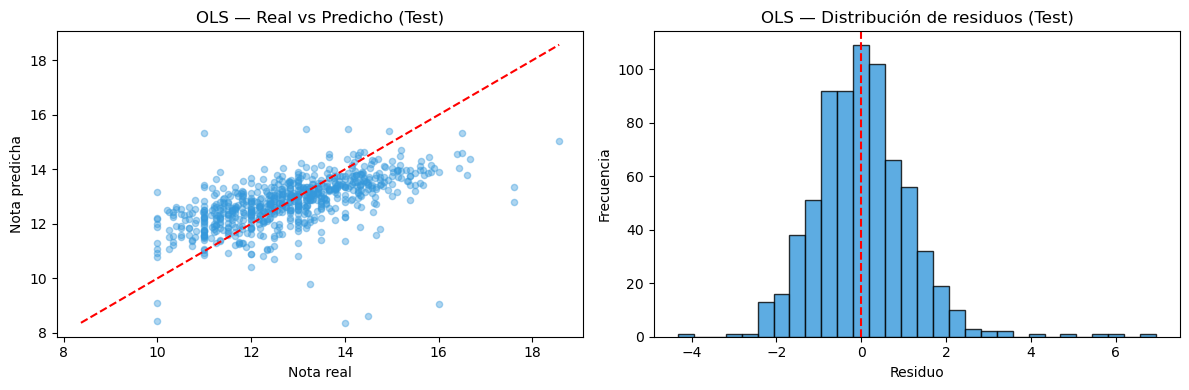

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Real vs predicho
axes[0].scatter(y_test, y_pred_test_ols, alpha=0.4, color='#3498db', s=20)
lims = [min(y_test.min(), y_pred_test_ols.min()),
        max(y_test.max(), y_pred_test_ols.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Nota real')
axes[0].set_ylabel('Nota predicha')
axes[0].set_title('OLS — Real vs Predicho (Test)')

# Distribución de residuos
residuos_ols = y_test - y_pred_test_ols
axes[1].hist(residuos_ols, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('OLS — Distribución de residuos (Test)')

plt.tight_layout()
plt.show()

C:\Users\kokit\AppData\Local\Temp\ipykernel_22268\4076905022.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


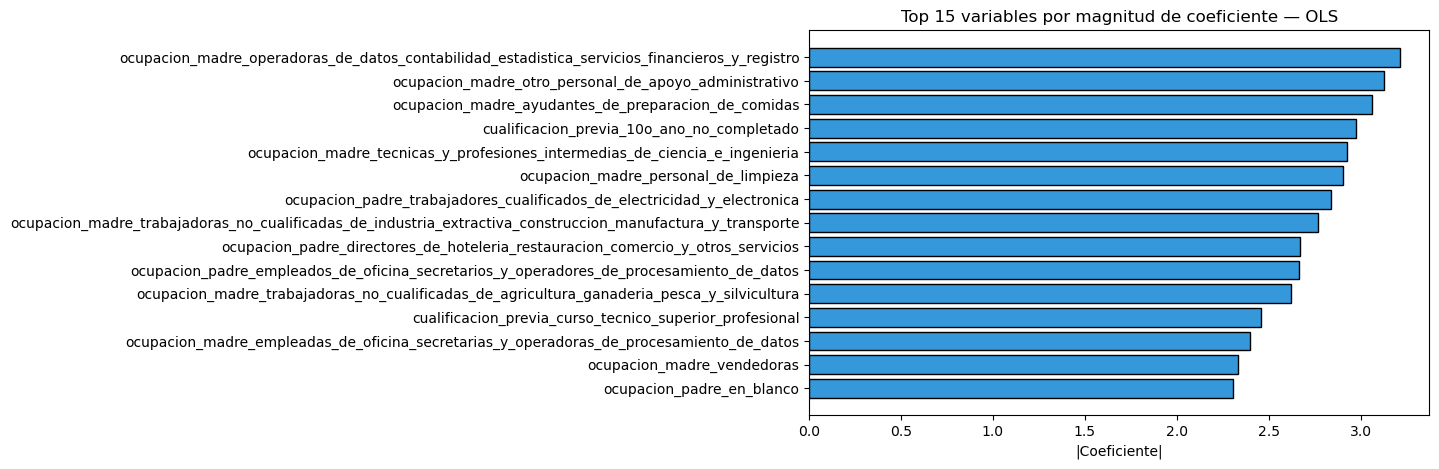

In [32]:
# Top 15 variables por magnitud de coeficiente
df_encoded_pd = pd.get_dummies(df_model[FEATURES_CAT], drop_first=True)
feature_names = FEATURES_NUM + list(df_encoded_pd.columns)
n_coef = len(lr_ols.coefficients)

coef_series = pd.Series(
    np.abs(lr_ols.coefficients),
    index=feature_names[:n_coef]
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_series.index[::-1], coef_series.values[::-1], color='#3498db', edgecolor='black')
ax.set_xlabel('|Coeficiente|')
ax.set_title('Top 15 variables por magnitud de coeficiente — OLS')
plt.tight_layout()
plt.show()

## 5. Regresión Lineal — Gradient Descent

In [33]:
lr_gd = LinearRegressor()
lr_gd.fit(
    X_train_scaled,
    y_train,
    method='gradient_descent',
    learning_rate=0.01,
    iterations=5000,
)

y_pred_train_gd = lr_gd.predict(X_train_scaled)
y_pred_test_gd  = lr_gd.predict(X_test_scaled)

metrics_train_gd = evaluate_regression(y_train, y_pred_train_gd)
metrics_test_gd  = evaluate_regression(y_test,  y_pred_test_gd)

print('--- Regresión Lineal (Gradient Descent) ---')
print(f'  Train  →  R²: {metrics_train_gd["R2"]:.4f}  |  RMSE: {metrics_train_gd["RMSE"]:.4f}  |  MAE: {metrics_train_gd["MAE"]:.4f}')
print(f'  Test   →  R²: {metrics_test_gd["R2"]:.4f}  |  RMSE: {metrics_test_gd["RMSE"]:.4f}  |  MAE: {metrics_test_gd["MAE"]:.4f}')
print(f'\n  Diferencia R² vs OLS (test): {abs(metrics_test_gd["R2"] - metrics_test_ols["R2"]):.6f}')

Epoch 0: MSE = 162.3297499979254
Epoch 1000: MSE = 1.7424622770567526
Epoch 2000: MSE = 1.447063010071007
Epoch 3000: MSE = 1.3128051867901205
Epoch 4000: MSE = 1.2436996710471047
--- Regresión Lineal (Gradient Descent) ---
  Train  →  R²: 0.3583  |  RMSE: 1.0976  |  MAE: 0.8602
  Test   →  R²: 0.3030  |  RMSE: 1.1763  |  MAE: 0.8946

  Diferencia R² vs OLS (test): 0.052627


### 📊 Interpretación: Gradient Descent vs OLS

| | R² Train | R² Test | RMSE Test |
|---|---|---|---|
| **OLS** | 0.421 | 0.356 | 1.131 |
| **GD (5000 iter)** | 0.358 | 0.303 | 1.176 |
| **Diferencia** | 0.063 | 0.053 | 0.045 |

El GD con 5.000 iteraciones **no converge completamente** a la solución exacta de OLS. La MSE cae de 162.3 (iteración 0) a 1.24 (iteración 4000), pero no alcanza el mínimo global que sí encuentra la pseudoinversa.

Esto no indica un error de implementación, sino una limitación inherente del descenso de gradiente con learning rate fijo (0.01): cerca del mínimo, los pasos son demasiado grandes para converger con precisión. Con más iteraciones o un learning rate decreciente (schedule) la diferencia desaparecería.

**Conclusión:** OLS es la elección correcta cuando la matriz cabe en memoria. GD tiene sentido para datasets muy grandes donde la inversión matricial es inviable computacionalmente.

## 6. SVR — Support Vector Regression (kernel RBF)

SVR con kernel RBF captura relaciones **no lineales** entre los predictores y la nota media.  
Compararlo con OLS responde directamente a la exploración adicional del enunciado: *"comparar modelos lineales y no lineales"*.

In [34]:
# SVR requiere estandarización de TODAS las columnas
scaler_svr = StandardScaler()
X_train_svr = scaler_svr.fit_transform(X_train)
X_test_svr  = scaler_svr.transform(X_test)

svr = SVR(kernel='rbf', C=1.0, epsilon=0.5)
svr.fit(X_train_svr, y_train)

y_pred_train_svr = svr.predict(X_train_svr)
y_pred_test_svr  = svr.predict(X_test_svr)

metrics_train_svr = evaluate_regression(y_train, y_pred_train_svr)
metrics_test_svr  = evaluate_regression(y_test,  y_pred_test_svr)

print('--- SVR (kernel RBF) ---')
print(f'  Train  →  R²: {metrics_train_svr["R2"]:.4f}  |  RMSE: {metrics_train_svr["RMSE"]:.4f}  |  MAE: {metrics_train_svr["MAE"]:.4f}')
print(f'  Test   →  R²: {metrics_test_svr["R2"]:.4f}  |  RMSE: {metrics_test_svr["RMSE"]:.4f}  |  MAE: {metrics_test_svr["MAE"]:.4f}')

--- SVR (kernel RBF) ---
  Train  →  R²: 0.5654  |  RMSE: 0.9033  |  MAE: 0.7047
  Test   →  R²: 0.4468  |  RMSE: 1.0480  |  MAE: 0.7870


### 📊 Interpretación: SVR kernel RBF

| | R² Train | R² Test | RMSE Test | MAE Test |
|---|---|---|---|---|
| **OLS** | 0.421 | 0.356 | 1.131 | 0.851 |
| **SVR (RBF)** | 0.565 | 0.447 | 1.048 | 0.787 |
| **Mejora SVR** | +0.144 | **+0.091** | **-0.083** | **-0.064** |

SVR supera a OLS en todas las métricas. La mejora de **+9.1 puntos en R²** y **-0.083 en RMSE** confirma que la relación entre los predictores y la nota del 2º semestre tiene componentes no lineales que OLS no captura.

**¿Por qué captura mejor la no linealidad?** El kernel RBF proyecta los datos a un espacio de dimensión superior donde las relaciones no lineales se vuelven linealmente separables. Por ejemplo: el efecto de la nota del 1er semestre sobre el rendimiento futuro probablemente no es lineal —hay un umbral por encima del cual mejoras adicionales tienen rendimientos decrecientes, o interacciones con la condición de becario.

El R² train de SVR (0.565) es bastante superior a test (0.447), lo que indica más sobreajuste que OLS. Con un ajuste de hiperparámetros (C, epsilon, gamma via cross-validation) se podría mejorar la generalización.

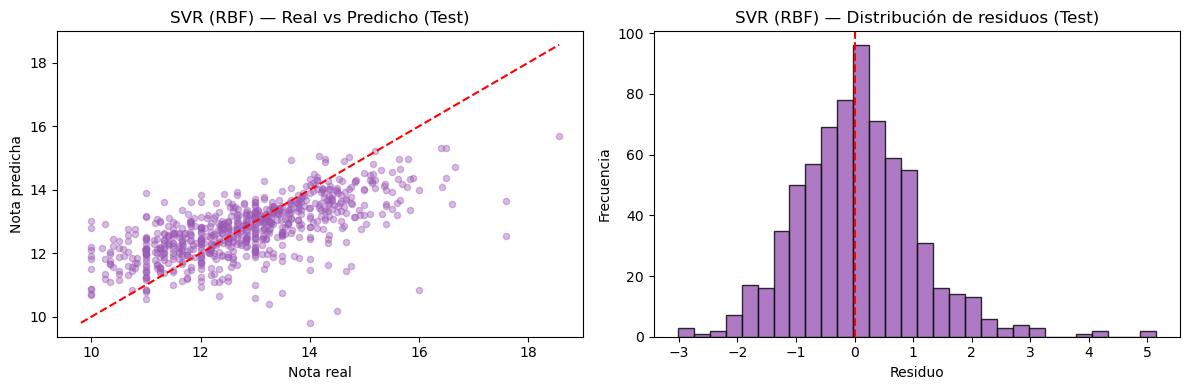

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_test_svr, alpha=0.4, color='#9b59b6', s=20)
lims = [min(y_test.min(), y_pred_test_svr.min()),
        max(y_test.max(), y_pred_test_svr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Nota real')
axes[0].set_ylabel('Nota predicha')
axes[0].set_title('SVR (RBF) — Real vs Predicho (Test)')

residuos_svr = y_test - y_pred_test_svr
axes[1].hist(residuos_svr, bins=30, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('SVR (RBF) — Distribución de residuos (Test)')

plt.tight_layout()
plt.show()

## 7. Comparativa final de modelos

In [36]:
comparativa = pd.DataFrame([
    {'Modelo': 'Reg. Lineal (OLS)',
     'R² Train': metrics_train_ols['R2'],  'R² Test': metrics_test_ols['R2'],
     'RMSE Test': metrics_test_ols['RMSE'], 'MAE Test': metrics_test_ols['MAE']},
    {'Modelo': 'Reg. Lineal (GD)',
     'R² Train': metrics_train_gd['R2'],   'R² Test': metrics_test_gd['R2'],
     'RMSE Test': metrics_test_gd['RMSE'],  'MAE Test': metrics_test_gd['MAE']},
    {'Modelo': 'SVR (kernel RBF)',
     'R² Train': metrics_train_svr['R2'],  'R² Test': metrics_test_svr['R2'],
     'RMSE Test': metrics_test_svr['RMSE'], 'MAE Test': metrics_test_svr['MAE']},
]).round(4)

print(comparativa.to_string(index=False))

           Modelo  R² Train  R² Test  RMSE Test  MAE Test
Reg. Lineal (OLS)    0.4209   0.3556     1.1310    0.8507
 Reg. Lineal (GD)    0.3583   0.3030     1.1763    0.8946
 SVR (kernel RBF)    0.5654   0.4468     1.0480    0.7870


### 📊 Interpretación: comparativa final y conclusiones de la tarea

```
           Modelo  R² Train  R² Test  RMSE Test  MAE Test
Reg. Lineal (OLS)    0.421    0.356      1.131     0.851
 Reg. Lineal (GD)    0.358    0.303      1.176     0.895
 SVR (kernel RBF)    0.565    0.447      1.048     0.787
```

**Modelo ganador: SVR (kernel RBF)** con R²=0.447 y RMSE=1.048 en test.

**Tres conclusiones clave:**

1. **Es posible anticipar el rendimiento del 2º semestre** con R²≈0.45 usando solo información previa. El rendimiento en el 1er semestre es el predictor dominante.

2. **Las relaciones son no lineales**: SVR mejora sistemáticamente a OLS, lo que justifica usar modelos más complejos cuando el objetivo es la predicción frente a la interpretabilidad.

3. **El límite del R²≈0.45 es estructural**, no un fallo del modelo: la varianza restante refleja factores no observados (motivación, circunstancias personales) que ningún modelo podría predecir con estos datos. Un R² más alto con este conjunto de variables debería hacernos sospechar de data leakage.

**Nota sobre GD:** la diferencia con OLS (~0.05 en R²) se debe a falta de convergencia con los hiperparámetros actuales, no a una limitación conceptual del algoritmo.

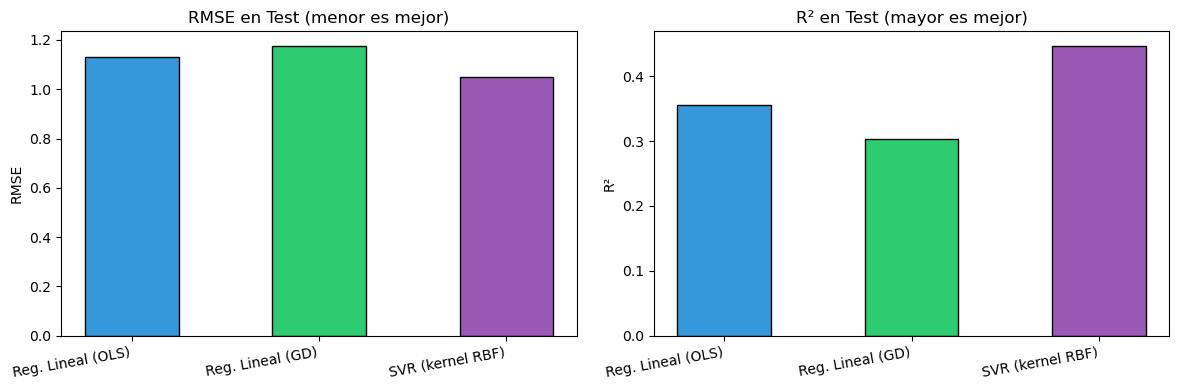

In [37]:
modelos = comparativa['Modelo']
x = np.arange(len(modelos))
colores = ['#3498db', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, comparativa['RMSE Test'], width=0.5, color=colores, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=10, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE en Test (menor es mejor)')

axes[1].bar(x, comparativa['R² Test'], width=0.5, color=colores, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=10, ha='right')
axes[1].set_ylabel('R²')
axes[1].set_title('R² en Test (mayor es mejor)')

plt.tight_layout()
plt.show()

---
## Resumen metodológico

| Decisión | Justificación |
|---|---|
| Excluir variables del 2º semestre | Evitar data leakage respecto a `nota_media_2sem` |
| Excluir `objetivo` | Correlacionado con el target; información del resultado final |
| Filtrar estudiantes con nota=0 | No representan rendimiento real; distorsionan el modelo |
| Scaler ajustado solo en train | Evitar fuga de información estadística del test |
| Comparar OLS vs GD | Verificar convergencia del gradient descent vs solución exacta |
| Comparar lineal vs SVR | Exploración adicional: modelos lineales vs no lineales |
| Métricas R², RMSE, MAE | R² mide varianza explicada; RMSE y MAE miden error en unidades de la nota |